
Dimensionless Heat Equation
Maximum Error : 3.156368e-03
L2 Error      : 2.234585e-03


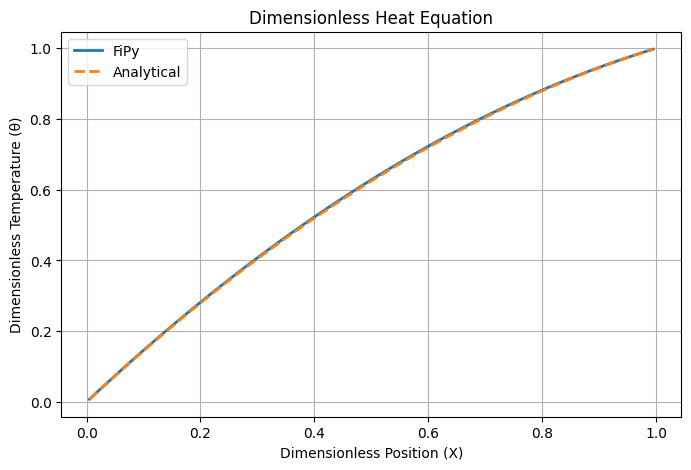

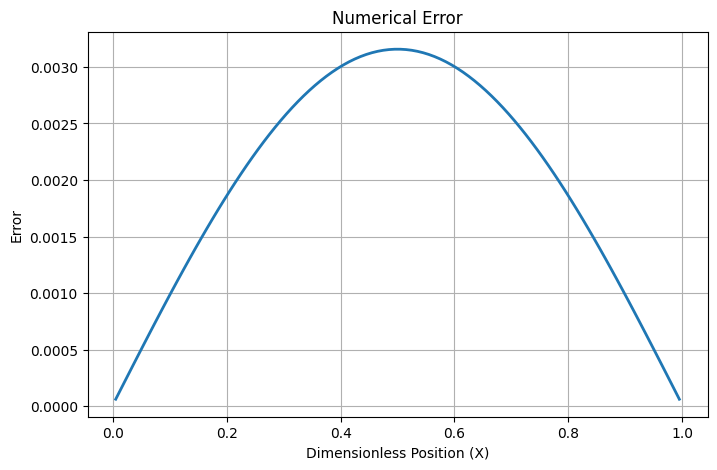

In [1]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DOMAIN
# ============================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

X = mesh.cellCenters[0].value

# ============================================================
# TIME
# ============================================================

dt = 1e-3
final_time = 1.0
steps = int(final_time / dt)

# ============================================================
# DIMENSIONLESS PARAMETERS
# ============================================================

Q_star = 1.0

# ============================================================
# DIMENSIONLESS TEMPERATURE
# ============================================================

theta = CellVariable(
    name="Dimensionless Temperature",
    mesh=mesh,
    value=np.sin(np.pi * X),
    hasOld=True
)

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

theta.constrain(0.0, mesh.facesLeft)
theta.constrain(1.0, mesh.facesRight)

# ============================================================
# DIMENSIONLESS HEAT EQUATION
#
# d(theta)/dt = d²(theta)/dx² + Q*
# ============================================================

heatEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + Q_star
)

# ============================================================
# TIME LOOP
# ============================================================

for step in range(steps):

    theta.updateOld()

    heatEq.solve(
        var=theta,
        dt=dt
    )

# ============================================================
# ANALYTICAL STEADY STATE
# ============================================================

theta_exact = (
    -0.5 * Q_star * X**2
    + (1 + 0.5 * Q_star) * X
)

# ============================================================
# ERROR
# ============================================================

error = theta.value - theta_exact

max_error = np.max(np.abs(error))
l2_error = np.sqrt(np.mean(error**2))

print("\n==============================")
print("Dimensionless Heat Equation")
print("==============================")
print(f"Maximum Error : {max_error:.6e}")
print(f"L2 Error      : {l2_error:.6e}")

# ============================================================
# PLOT 1
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    X,
    theta.value,
    linewidth=2,
    label="FiPy"
)

plt.plot(
    X,
    theta_exact,
    "--",
    linewidth=2,
    label="Analytical"
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel("Dimensionless Temperature (θ)")
plt.title("Dimensionless Heat Equation")
plt.grid(True)
plt.legend()

plt.show()

# ============================================================
# PLOT 2
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    X,
    error,
    linewidth=2
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel("Error")
plt.title("Numerical Error")
plt.grid(True)

plt.show()


Steady state reached after 440 steps

Dimensionless Heat Equation
Maximum Error : 3.156368e-03
L2 Error      : 2.234585e-03


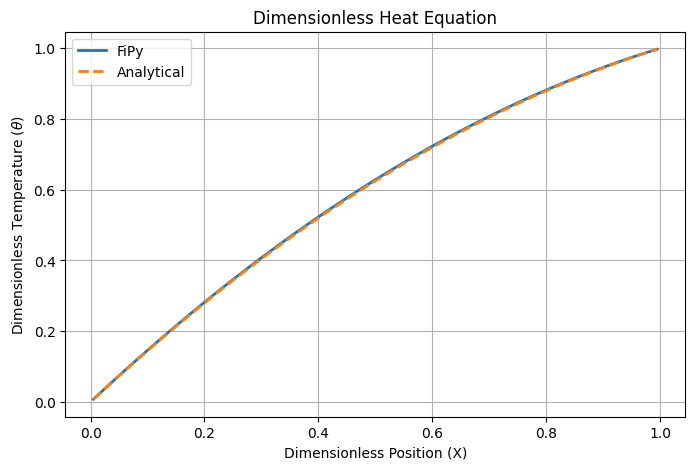

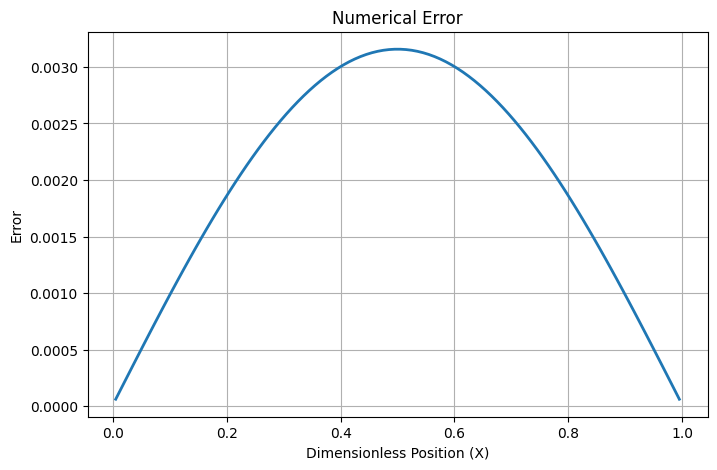

In [2]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DOMAIN
# ============================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
X = mesh.cellCenters[0].value

# ============================================================
# TIME
# ============================================================

dt = 1e-3
final_time = 20.0          # Increased
steps = int(final_time / dt)

tolerance = 1e-8           # Steady-state tolerance

# ============================================================
# DIMENSIONLESS PARAMETERS
# ============================================================

Q_star = 1.0

# ============================================================
# VARIABLE
# ============================================================

theta = CellVariable(
    name="Dimensionless Temperature",
    mesh=mesh,
    value=np.sin(np.pi * X),
    hasOld=True
)

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

theta.constrain(0.0, mesh.facesLeft)
theta.constrain(1.0, mesh.facesRight)

# ============================================================
# DIMENSIONLESS HEAT EQUATION
# dθ/dτ = ∇²θ + Q*
# ============================================================

heatEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + Q_star
)

# ============================================================
# TIME LOOP
# ============================================================

for step in range(steps):

    theta.updateOld()

    heatEq.solve(var=theta, dt=dt)

    max_change = np.max(np.abs(theta.value - theta.old.value))

    if max_change < tolerance:
        print(f"\nSteady state reached after {step+1} steps")
        break

# ============================================================
# ANALYTICAL SOLUTION
# ============================================================

theta_exact = (
    -0.5 * Q_star * X**2
    + (1 + 0.5 * Q_star) * X
)

# ============================================================
# ERROR
# ============================================================

error = theta.value - theta_exact

max_error = np.max(np.abs(error))
l2_error = np.sqrt(np.mean(error**2))

print("\n==============================")
print("Dimensionless Heat Equation")
print("==============================")
print(f"Maximum Error : {max_error:.6e}")
print(f"L2 Error      : {l2_error:.6e}")

# ============================================================
# PLOT 1
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(X, theta.value,
         linewidth=2,
         label='FiPy')

plt.plot(X, theta_exact,
         '--',
         linewidth=2,
         label='Analytical')

plt.xlabel("Dimensionless Position (X)")
plt.ylabel(r"Dimensionless Temperature ($\theta$)")
plt.title("Dimensionless Heat Equation")

plt.grid(True)
plt.legend()

plt.show()

# ============================================================
# PLOT 2
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(X, error,
         linewidth=2)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel("Error")
plt.title("Numerical Error")

plt.grid(True)

plt.show()


Running for nx = 25

Running for nx = 50

Running for nx = 100

Running for nx = 200

Running for nx = 400


Mesh Convergence Study
    nx           dx          Max Error           L2 Error
-----------------------------------------------------------------
    25     0.040000       1.292932e-03       9.569460e-04
    50     0.020000       1.570548e-03       1.120954e-03
   100     0.010000       3.156368e-03       2.234585e-03
   200     0.005000       8.233875e-03       5.823005e-03
   400     0.002500       2.285862e-02       1.616360e-02

Observed Order of Convergence
 25 ->  50 : p = -0.2806
 50 -> 100 : p = -1.0070
100 -> 200 : p = -1.3833
200 -> 400 : p = -1.4731


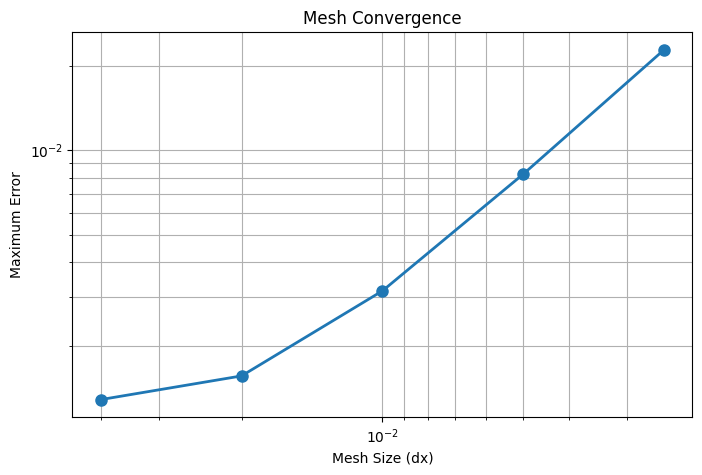

In [3]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DIMENSIONLESS PARAMETERS
# ============================================================

Q_star = 1.0

# ============================================================
# TIME
# ============================================================

dt = 1e-3
final_time = 20.0
steps = int(final_time / dt)

tolerance = 1e-8

# ============================================================
# MESH CONVERGENCE STUDY
# ============================================================

mesh_sizes = [25, 50, 100, 200, 400]

results = []

for nx in mesh_sizes:

    print(f"\nRunning for nx = {nx}")

    # --------------------------------------------------------
    # DOMAIN
    # --------------------------------------------------------

    L = 1.0
    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)

    X = mesh.cellCenters[0].value

    # --------------------------------------------------------
    # VARIABLE
    # --------------------------------------------------------

    theta = CellVariable(
        mesh=mesh,
        value=np.sin(np.pi * X),
        hasOld=True
    )

    # --------------------------------------------------------
    # BOUNDARY CONDITIONS
    # --------------------------------------------------------

    theta.constrain(0.0, mesh.facesLeft)
    theta.constrain(1.0, mesh.facesRight)

    # --------------------------------------------------------
    # EQUATION
    # --------------------------------------------------------

    heatEq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + Q_star
    )

    # --------------------------------------------------------
    # TIME LOOP
    # --------------------------------------------------------

    for step in range(steps):

        theta.updateOld()

        heatEq.solve(var=theta, dt=dt)

        max_change = np.max(np.abs(theta.value - theta.old.value))

        if max_change < tolerance:
            break

    # --------------------------------------------------------
    # ANALYTICAL SOLUTION
    # --------------------------------------------------------

    theta_exact = (
        -0.5 * Q_star * X**2
        + (1 + 0.5 * Q_star) * X
    )

    # --------------------------------------------------------
    # ERROR
    # --------------------------------------------------------

    error = theta.value - theta_exact

    max_error = np.max(np.abs(error))
    l2_error = np.sqrt(np.mean(error**2))

    results.append([nx, dx, max_error, l2_error])

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n")
print("="*65)
print("Mesh Convergence Study")
print("="*65)

print(f"{'nx':>6} {'dx':>12} {'Max Error':>18} {'L2 Error':>18}")

print("-"*65)

for r in results:

    print(f"{r[0]:6d} {r[1]:12.6f} {r[2]:18.6e} {r[3]:18.6e}")

# ============================================================
# OBSERVED ORDER OF CONVERGENCE
# ============================================================

print("\nObserved Order of Convergence")

for i in range(len(results)-1):

    h1 = results[i][1]
    h2 = results[i+1][1]

    e1 = results[i][2]
    e2 = results[i+1][2]

    p = np.log(e1/e2) / np.log(h1/h2)

    print(f"{results[i][0]:3d} -> {results[i+1][0]:3d} : p = {p:.4f}")

# ============================================================
# PLOT
# ============================================================

dx_values = [r[1] for r in results]
max_errors = [r[2] for r in results]

plt.figure(figsize=(8,5))

plt.loglog(dx_values,
           max_errors,
           'o-',
           linewidth=2,
           markersize=8)

plt.gca().invert_xaxis()

plt.xlabel("Mesh Size (dx)")
plt.ylabel("Maximum Error")
plt.title("Mesh Convergence")

plt.grid(True, which="both")

plt.show()

Computing reference solution...
Running nx = 25
Running nx = 50
Running nx = 100
Running nx = 200
Running nx = 400


Mesh Convergence
    nx         dx          Max Error           L2 Error
    25   0.040000       6.281445e-02       4.439657e-02
    50   0.020000       6.262572e-02       4.422883e-02
   100   0.010000       6.106357e-02       4.311552e-02
   200   0.005000       5.600406e-02       3.952902e-02
   400   0.002500       4.141957e-02       2.919565e-02

Observed Order
 25 ->  50 : p = 0.0055
 50 -> 100 : p = 0.0368
100 -> 200 : p = 0.1253
200 -> 400 : p = 0.4372


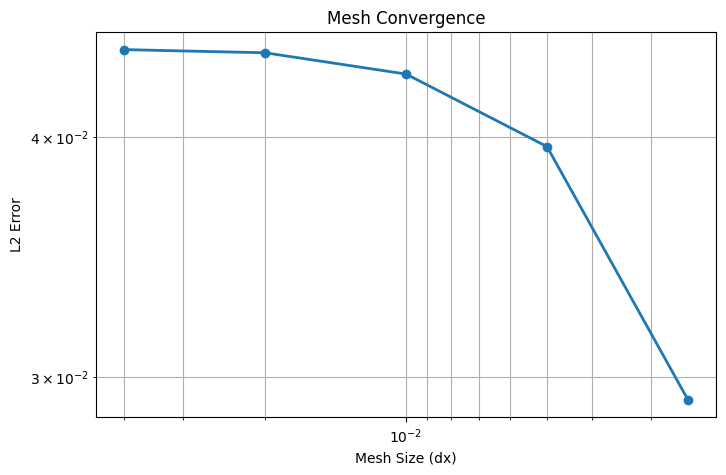

In [4]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================

Q_star = 1.0

dt = 1e-3
final_time = 20.0
steps = int(final_time / dt)

tolerance = 1e-8

mesh_sizes = [25, 50, 100, 200, 400]
reference_nx = 800

# ============================================================
# FUNCTION TO SOLVE THE HEAT EQUATION
# ============================================================

def solve_heat(nx):

    L = 1.0
    dx = L / nx

    mesh = Grid1D(nx=nx, dx=dx)
    X = mesh.cellCenters[0].value

    theta = CellVariable(
        mesh=mesh,
        value=np.sin(np.pi * X),
        hasOld=True
    )

    theta.constrain(0.0, mesh.facesLeft)
    theta.constrain(1.0, mesh.facesRight)

    heatEq = (
        TransientTerm()
        ==
        DiffusionTerm(coeff=1.0)
        + Q_star
    )

    for step in range(steps):

        theta.updateOld()

        heatEq.solve(var=theta, dt=dt)

        if np.max(np.abs(theta.value - theta.old.value)) < tolerance:
            break

    return X, theta.value

# ============================================================
# REFERENCE SOLUTION
# ============================================================

print("Computing reference solution...")

X_ref, theta_ref = solve_heat(reference_nx)

# ============================================================
# CONVERGENCE STUDY
# ============================================================

results = []

for nx in mesh_sizes:

    print(f"Running nx = {nx}")

    X, theta = solve_heat(nx)

    # Interpolate reference solution onto coarse mesh
    theta_interp = np.interp(X, X_ref, theta_ref)

    error = theta - theta_interp

    max_error = np.max(np.abs(error))
    l2_error = np.sqrt(np.mean(error**2))

    results.append([nx, 1.0/nx, max_error, l2_error])

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n")
print("="*70)
print("Mesh Convergence")
print("="*70)

print(f"{'nx':>6} {'dx':>10} {'Max Error':>18} {'L2 Error':>18}")

for r in results:

    print(f"{r[0]:6d} {r[1]:10.6f} {r[2]:18.6e} {r[3]:18.6e}")

# ============================================================
# OBSERVED ORDER
# ============================================================

print("\nObserved Order")

for i in range(len(results)-1):

    h1 = results[i][1]
    h2 = results[i+1][1]

    e1 = results[i][3]      # L2 error
    e2 = results[i+1][3]

    p = np.log(e1/e2)/np.log(h1/h2)

    print(f"{results[i][0]:3d} -> {results[i+1][0]:3d} : p = {p:.4f}")

# ============================================================
# PLOT
# ============================================================

dx = [r[1] for r in results]
l2 = [r[3] for r in results]

plt.figure(figsize=(8,5))

plt.loglog(dx, l2, 'o-', linewidth=2)

plt.gca().invert_xaxis()

plt.xlabel("Mesh Size (dx)")
plt.ylabel("L2 Error")
plt.title("Mesh Convergence")

plt.grid(True, which='both')

plt.show()

# Dimensionless Heat Equation: Mathematical Derivation

## Objective

The objective of this notebook is to derive the dimensionless form of the one-dimensional transient heat diffusion equation with a uniform volumetric heat source. This dimensionless formulation simplifies the governing equation by reducing the number of physical parameters and provides a convenient framework for numerical implementation and analysis.

---

# 1. Dimensional Governing Equation

The one-dimensional transient heat diffusion equation with a uniform volumetric heat source is

$$
\rho C_p\frac{\partial T}{\partial t}
=
k\frac{\partial^2T}{\partial x^2}
+
Q
$$

where

| Symbol | Description | Unit |
|---------|-------------|------|
| $T$ | Temperature | K |
| $t$ | Time | s |
| $x$ | Spatial coordinate | m |
| $\rho$ | Density | kg/m$^3$ |
| $C_p$ | Specific heat capacity | J/(kg K) |
| $k$ | Thermal conductivity | W/(m K) |
| $Q$ | Volumetric heat generation | W/m$^3$ |

---

# 2. Thermal Diffusivity

The thermal diffusivity is defined as

$$
\alpha=\frac{k}{\rho C_p}
$$

which has units of

$$
m^2/s.
$$

The governing equation can therefore be written as

$$
\frac{\partial T}{\partial t}
=
\alpha
\frac{\partial^2T}{\partial x^2}
+
\frac{Q}{\rho C_p}.
$$

---

# 3. Choice of Characteristic Scales

To nondimensionalize the equation, characteristic scales are introduced.

## Characteristic Length

Let

$$
L
$$

be the characteristic length of the domain.

Define the dimensionless spatial coordinate

$$
X=\frac{x}{L}.
$$

Hence

$$
0\le X\le1.
$$

---

## Characteristic Time

The characteristic diffusion time is chosen as

$$
t_c=\frac{L^2}{\alpha}.
$$

The dimensionless time is therefore

$$
\tau=\frac{t}{t_c}
=
\frac{\alpha t}{L^2}.
$$

---

## Characteristic Temperature

Choose

- $T_0$ as the reference temperature.
- $\Delta T$ as the characteristic temperature difference.

The dimensionless temperature is

$$
\theta
=
\frac{T-T_0}{\Delta T}.
$$

Hence

$$
T=T_0+\Delta T\,\theta.
$$

---

# 4. Transformation of Derivatives

## Time Derivative

Using the chain rule,

$$
\frac{\partial T}{\partial t}
=
\Delta T
\frac{\alpha}{L^2}
\frac{\partial\theta}{\partial\tau}.
$$

---

## First Spatial Derivative

Since

$$
x=LX,
$$

the first derivative becomes

$$
\frac{\partial T}{\partial x}
=
\frac{\Delta T}{L}
\frac{\partial\theta}{\partial X}.
$$

---

## Second Spatial Derivative

Differentiating once more,

$$
\frac{\partial^2T}{\partial x^2}
=
\frac{\Delta T}{L^2}
\frac{\partial^2\theta}{\partial X^2}.
$$

---

# 5. Substitution into the Governing Equation

Substituting the transformed derivatives into the dimensional equation,

$$
\rho C_p
\left(
\Delta T
\frac{\alpha}{L^2}
\frac{\partial\theta}{\partial\tau}
\right)
=
k
\left(
\frac{\Delta T}{L^2}
\frac{\partial^2\theta}{\partial X^2}
\right)
+
Q.
$$

Since

$$
\alpha=\frac{k}{\rho C_p},
$$

the left-hand side simplifies to

$$
\frac{k\Delta T}{L^2}
\frac{\partial\theta}{\partial\tau}.
$$

Thus,

$$
\frac{k\Delta T}{L^2}
\frac{\partial\theta}{\partial\tau}
=
\frac{k\Delta T}{L^2}
\frac{\partial^2\theta}{\partial X^2}
+
Q.
$$

Dividing every term by

$$
\frac{k\Delta T}{L^2},
$$

gives

$$
\boxed{
\frac{\partial\theta}{\partial\tau}
=
\frac{\partial^2\theta}{\partial X^2}
+
Q^*
}
$$

where

$$
\boxed{
Q^*
=
\frac{QL^2}{k\Delta T}
}
$$

is the **dimensionless heat source**.

---

# 6. Dimensionless Governing Equation

The final dimensionless heat equation is

$$
\boxed{
\frac{\partial\theta}{\partial\tau}
=
\frac{\partial^2\theta}{\partial X^2}
+
Q^*
}
$$

---

# 7. Boundary Conditions

Suppose the dimensional boundary conditions are

$$
T(0,t)=T_L,
$$

$$
T(L,t)=T_R.
$$

Using

$$
\theta=\frac{T-T_0}{\Delta T},
$$

the dimensionless boundary conditions become

$$
\theta(0,\tau)
=
\frac{T_L-T_0}{\Delta T},
$$

$$
\theta(1,\tau)
=
\frac{T_R-T_0}{\Delta T}.
$$

Choosing

$$
T_0=T_L,
$$

and

$$
\Delta T=T_R-T_L,
$$

gives

$$
\boxed{
\theta(0,\tau)=0,
\qquad
\theta(1,\tau)=1.
}
$$

---

# 8. Initial Condition

If the dimensional initial condition is

$$
T(x,0)=f(x),
$$

then the dimensionless initial condition becomes

$$
\boxed{
\theta(X,0)
=
\frac{f(x)-T_0}{\Delta T}.
}
$$

For the present study,

$$
\boxed{
\theta(X,0)=\sin(\pi X).
}
$$

---

# 9. Steady-State Analytical Solution

At steady state,

$$
\frac{\partial\theta}{\partial\tau}=0.
$$

Therefore,

$$
\frac{d^2\theta}{dX^2}
+
Q^*
=
0.
$$

Integrating once,

$$
\frac{d\theta}{dX}
=
-Q^*X+C_1.
$$

Integrating again,

$$
\theta(X)
=
-\frac{Q^*}{2}X^2
+
C_1X
+
C_2.
$$

Applying the boundary conditions

$$
\theta(0)=0,
$$

$$
\theta(1)=1,
$$

gives

$$
C_2=0,
$$

and

$$
C_1
=
1+\frac{Q^*}{2}.
$$

Hence, the analytical steady-state solution is

$$
\boxed{
\theta(X)
=
-\frac{Q^*}{2}X^2
+
\left(
1+\frac{Q^*}{2}
\right)X
}
$$

---

# 10. Summary of Dimensionless Parameters

| Symbol | Definition | Physical Meaning |
|---------|------------|------------------|
| $X$ | $\dfrac{x}{L}$ | Dimensionless position |
| $\tau$ | $\dfrac{\alpha t}{L^2}$ | Dimensionless time |
| $\theta$ | $\dfrac{T-T_0}{\Delta T}$ | Dimensionless temperature |
| $\alpha$ | $\dfrac{k}{\rho C_p}$ | Thermal diffusivity |
| $Q^*$ | $\dfrac{QL^2}{k\Delta T}$ | Dimensionless heat source |

---

# Conclusion

The dimensional heat diffusion equation has been transformed into a dimensionless form using characteristic length, time, and temperature scales. The resulting equation contains only one dimensionless parameter, the heat source term $Q^*$, making it more suitable for numerical simulation and parameter studies. This dimensionless equation will be implemented and validated using the finite volume method in the next notebook.

Starting transient simulation...

Steady state reached after 440 time steps.

Dimensionless Heat Equation Results
Maximum Error : 3.156368e-03
L2 Error      : 2.234585e-03


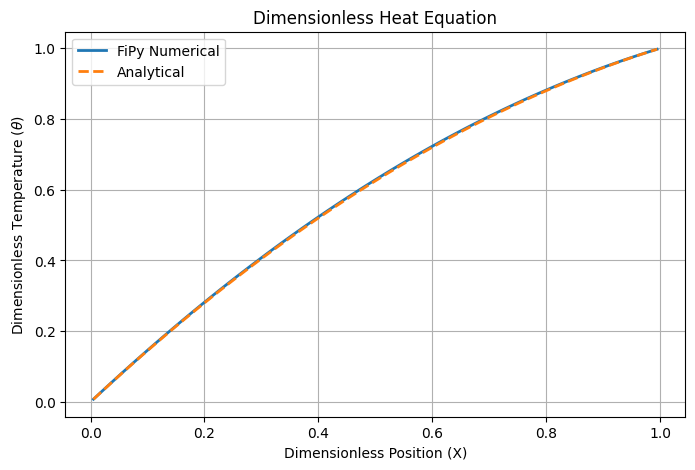

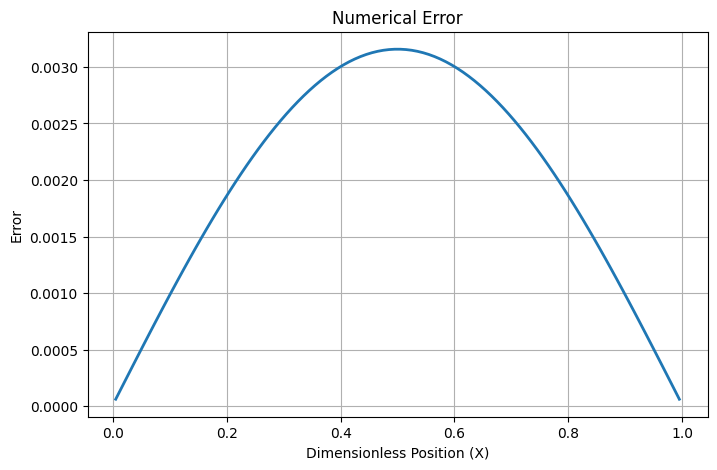

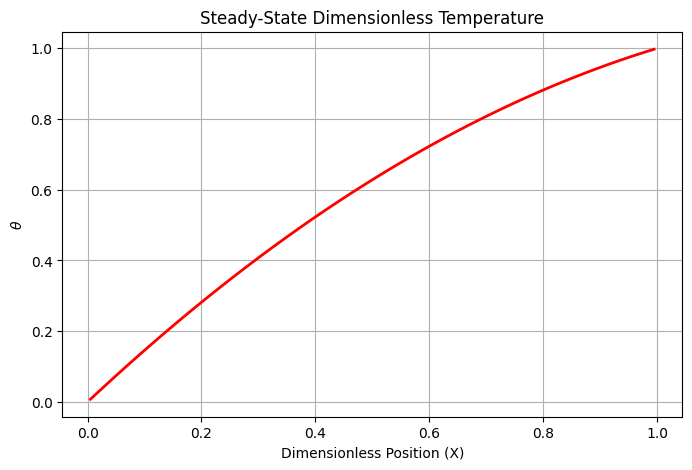



VALIDATION SUMMARY
Dimensionless Heat Source (Q*) : 1.0
Number of Cells                : 100
Time Step                      : 0.001
Steady-State Steps             : 440

Error Metrics
----------------------------
Maximum Error : 3.156368e-03
L2 Error      : 2.234585e-03

Result : PASS
The numerical solution agrees well with the analytical solution.


In [7]:
from fipy import *
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Dimensionless Heat Equation
#
# ∂θ/∂τ = ∂²θ/∂X² + Q*
# ============================================================

# ============================================================
# DOMAIN
# ============================================================

L = 1.0
nx = 100
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)

X = mesh.cellCenters[0].value

# ============================================================
# TIME
# ============================================================

dt = 1e-3
final_time = 20.0
steps = int(final_time / dt)

steady_tolerance = 1e-8

# ============================================================
# DIMENSIONLESS PARAMETERS
# ============================================================

Q_star = 1.0

# ============================================================
# INITIAL CONDITION
# ============================================================

theta = CellVariable(
    name="Dimensionless Temperature",
    mesh=mesh,
    value=np.sin(np.pi * X),
    hasOld=True
)

# ============================================================
# BOUNDARY CONDITIONS
# ============================================================

theta.constrain(0.0, mesh.facesLeft)
theta.constrain(1.0, mesh.facesRight)

# ============================================================
# DIMENSIONLESS HEAT EQUATION
# ============================================================

heatEq = (
    TransientTerm()
    ==
    DiffusionTerm(coeff=1.0)
    + Q_star
)

# ============================================================
# TIME INTEGRATION
# ============================================================

print("Starting transient simulation...\n")

for step in range(steps):

    theta.updateOld()

    heatEq.solve(var=theta, dt=dt)

    max_change = np.max(np.abs(theta.value - theta.old.value))

    if max_change < steady_tolerance:

        print(f"Steady state reached after {step+1} time steps.")

        break

# ============================================================
# ANALYTICAL STEADY STATE SOLUTION
# ============================================================

theta_exact = (
    -0.5 * Q_star * X**2
    + (1 + 0.5 * Q_star) * X
)

# ============================================================
# ERROR ANALYSIS
# ============================================================

error = theta.value - theta_exact

max_error = np.max(np.abs(error))
l2_error = np.sqrt(np.mean(error**2))

print("\n===================================")
print("Dimensionless Heat Equation Results")
print("===================================")

print(f"Maximum Error : {max_error:.6e}")
print(f"L2 Error      : {l2_error:.6e}")

# ============================================================
# PLOT : NUMERICAL VS ANALYTICAL
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    X,
    theta.value,
    linewidth=2,
    label="FiPy Numerical"
)

plt.plot(
    X,
    theta_exact,
    "--",
    linewidth=2,
    label="Analytical"
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel(r"Dimensionless Temperature ($\theta$)")
plt.title("Dimensionless Heat Equation")

plt.grid(True)
plt.legend()

plt.show()

# ============================================================
# PLOT : ERROR
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    X,
    error,
    linewidth=2
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel("Error")

plt.title("Numerical Error")

plt.grid(True)

plt.show()

# ============================================================
# PLOT : FINAL TEMPERATURE
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    X,
    theta.value,
    linewidth=2,
    color="red"
)

plt.xlabel("Dimensionless Position (X)")
plt.ylabel(r"$\theta$")

plt.title("Steady-State Dimensionless Temperature")

plt.grid(True)

plt.show()

# ============================================================
# VALIDATION SUMMARY
# ============================================================

print("\n")
print("="*60)
print("VALIDATION SUMMARY")
print("="*60)

print(f"Dimensionless Heat Source (Q*) : {Q_star}")
print(f"Number of Cells                : {nx}")
print(f"Time Step                      : {dt}")
print(f"Steady-State Steps             : {step+1}")

print("\nError Metrics")
print("----------------------------")
print(f"Maximum Error : {max_error:.6e}")
print(f"L2 Error      : {l2_error:.6e}")

if max_error < 1e-2:
    print("\nResult : PASS")
    print("The numerical solution agrees well with the analytical solution.")
else:
    print("\nResult : CHECK")
    print("Further mesh refinement may be required.")

print("="*60)